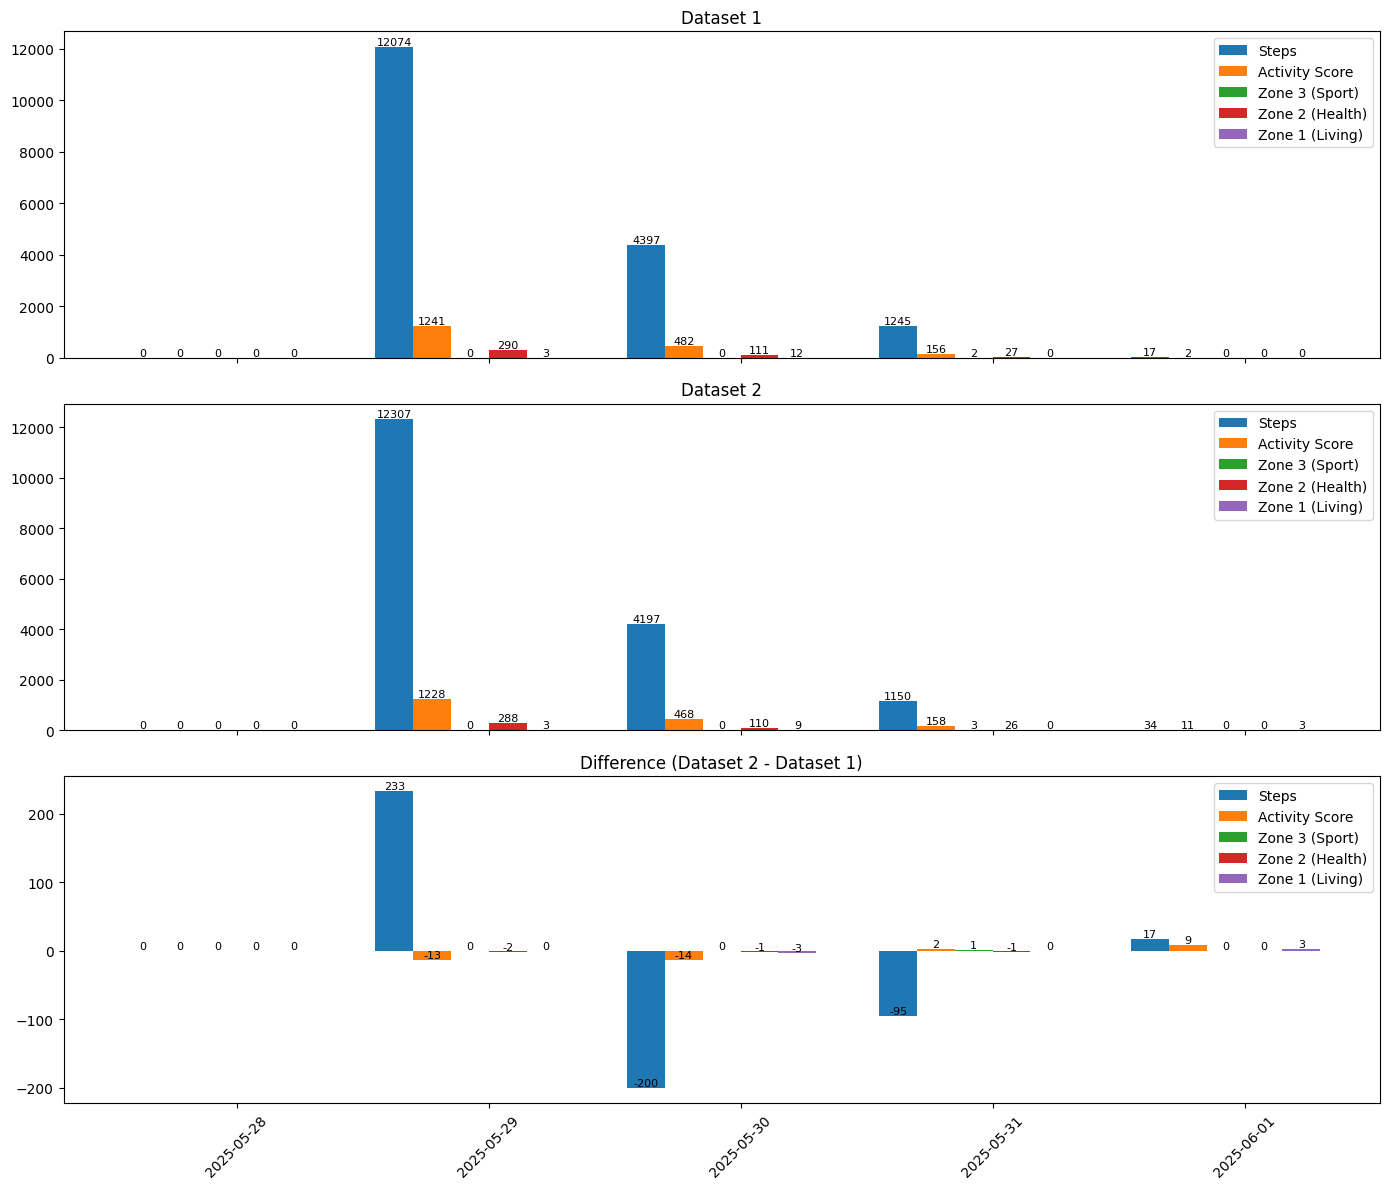

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSVs
df1 = pd.read_csv("./data/dayData_90242_3_experiment.csv", parse_dates=["Date"])
df2 = pd.read_csv("./data/dayData_90248_3_experiment.csv ", parse_dates=["Date"])

# Parse and set index
df1["Date"] = pd.to_datetime(df1["Date"])
df2["Date"] = pd.to_datetime(df2["Date"])
df1.set_index("Date", inplace=True)
df2.set_index("Date", inplace=True)

# Metrics and setup
metrics = ["Steps", "Activity Score", "Zone 3 (Sport)", "Zone 2 (Health)", "Zone 1 (Living)"]
dates = df1.index.strftime("%Y-%m-%d")
x = np.arange(len(dates))
width = 0.15

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Helper function to add value labels
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}', 
                ha='center', va='bottom', fontsize=8)

# Dataset 1
for i, metric in enumerate(metrics):
    bars = axes[0].bar(x + i * width, df1[metric], width, label=metric)
    add_labels(axes[0], bars)
axes[0].set_title("Dataset 1")
axes[0].legend()

# Dataset 2
for i, metric in enumerate(metrics):
    bars = axes[1].bar(x + i * width, df2[metric], width, label=metric)
    add_labels(axes[1], bars)
axes[1].set_title("Dataset 2")
axes[1].legend()

# Difference
diff = df2[metrics] - df1[metrics]
for i, metric in enumerate(metrics):
    bars = axes[2].bar(x + i * width, diff[metric], width, label=metric)
    add_labels(axes[2], bars)
axes[2].set_title("Difference (Dataset 2 - Dataset 1)")
axes[2].legend()

# X-axis settings
plt.xticks(ticks=x + (width * len(metrics) / 2), labels=dates, rotation=45)
plt.tight_layout()
plt.show()


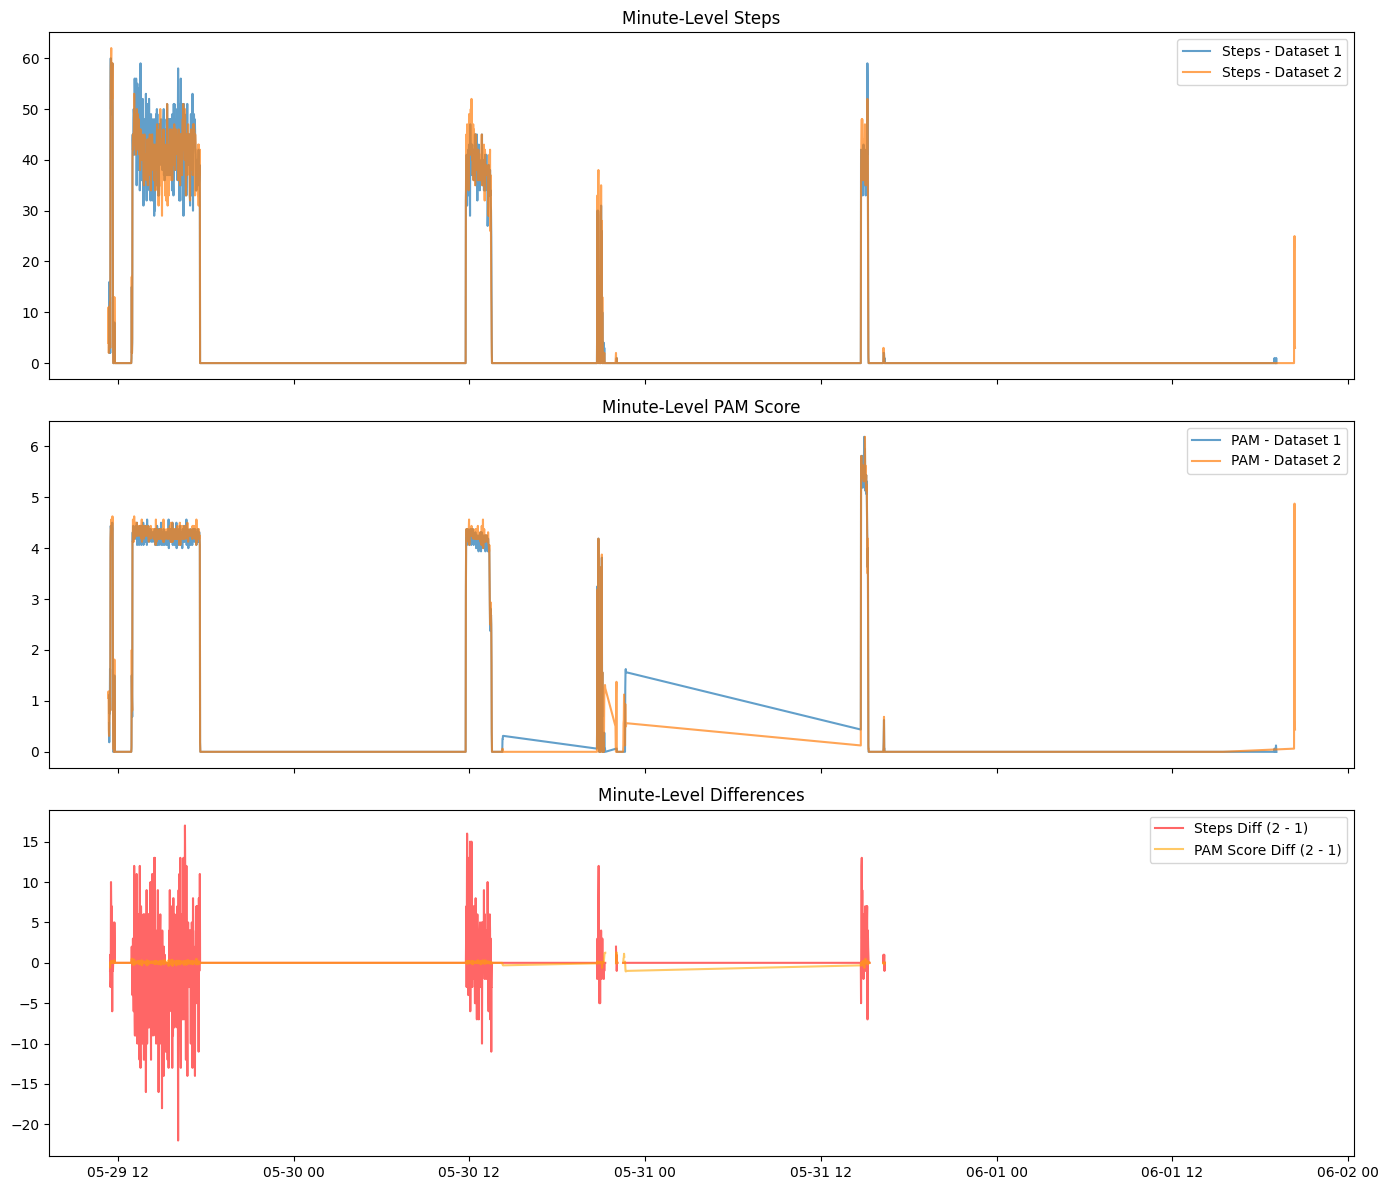

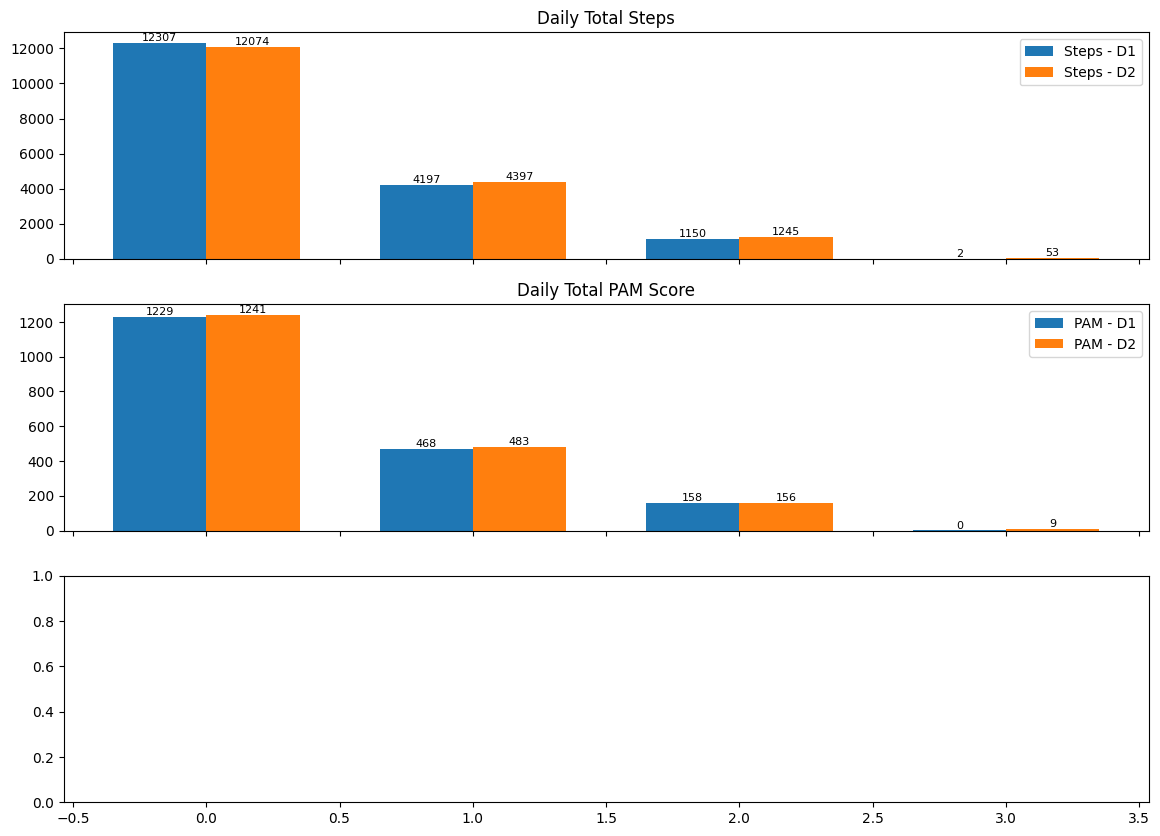

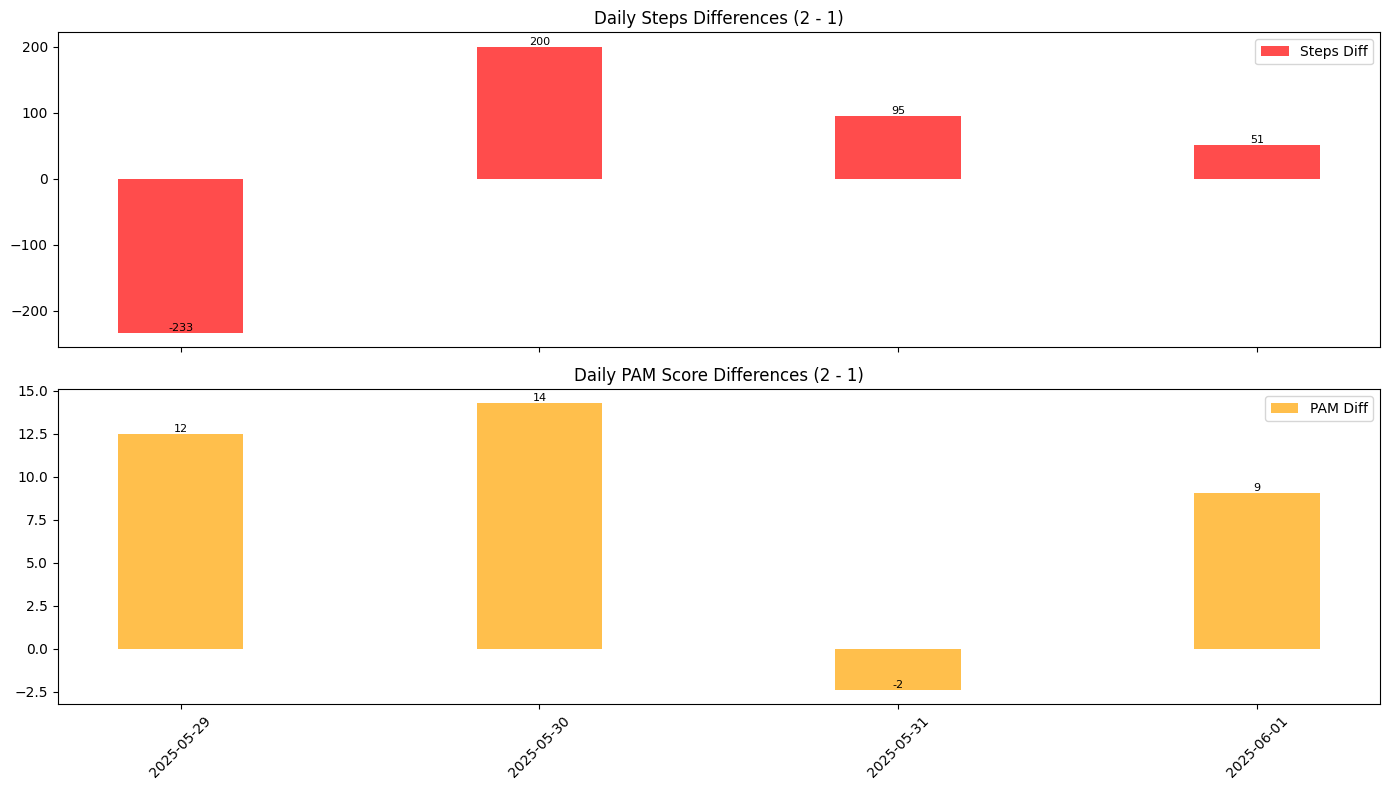

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the minute-level data
df1 = pd.read_csv("./data/device__8__3.csv", parse_dates=["Timestamp"])
df2 = pd.read_csv("./data/device__2__3.csv", parse_dates=["Timestamp"])

# Set timestamp as index
df1.set_index("Timestamp", inplace=True)
df2.set_index("Timestamp", inplace=True)

# --- 1. Plot raw minute-level data ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot Steps per minute
axes[0].plot(df1.index, df1["Steps"], label="Steps - Dataset 1", alpha=0.7)
axes[0].plot(df2.index, df2["Steps"], label="Steps - Dataset 2", alpha=0.7)
axes[0].set_title("Minute-Level Steps")
axes[0].legend()

# Plot PAM Score per minute
axes[1].plot(df1.index, df1["PAM Score"], label="PAM - Dataset 1", alpha=0.7)
axes[1].plot(df2.index, df2["PAM Score"], label="PAM - Dataset 2", alpha=0.7)
axes[1].set_title("Minute-Level PAM Score")
axes[1].legend()

# Plot differences
diff_steps = df2["Steps"] - df1["Steps"]
diff_pam = df2["PAM Score"] - df1["PAM Score"]

axes[2].plot(diff_steps.index, diff_steps, label="Steps Diff (2 - 1)", color="red", alpha=0.6)
axes[2].plot(diff_pam.index, diff_pam, label="PAM Score Diff (2 - 1)", color="orange", alpha=0.6)
axes[2].set_title("Minute-Level Differences")
axes[2].legend()

plt.tight_layout()
plt.show()

# --- 2. Resample to daily totals ---
df1_daily = df1.resample("D").sum()
df2_daily = df2.resample("D").sum()
daily_diff = df2_daily - df1_daily
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        if height != 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.0f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

# --- 3. Plot daily totals and differences ---
dates = df1_daily.index.strftime("%Y-%m-%d")
x = np.arange(len(dates))
width = 0.35

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Dataset 1
bars1 = axes[0].bar(x - width/2, df1_daily["Steps"], width, label="Steps - D1")
bars2 = axes[0].bar(x + width/2, df2_daily["Steps"], width, label="Steps - D2")
axes[0].set_title("Daily Total Steps")
axes[0].legend()
add_labels(axes[0], bars1)
add_labels(axes[0], bars2)

# Dataset 2
bars3 = axes[1].bar(x - width/2, df1_daily["PAM Score"], width, label="PAM - D1")
bars4 = axes[1].bar(x + width/2, df2_daily["PAM Score"], width, label="PAM - D2")
axes[1].set_title("Daily Total PAM Score")
axes[1].legend()
add_labels(axes[1], bars3)
add_labels(axes[1], bars4)

# --- Differences split into two separate plots ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Steps difference
bars5 = axes[0].bar(x, daily_diff["Steps"], width, label="Steps Diff", color="red", alpha=0.7)
axes[0].set_title("Daily Steps Differences (2 - 1)")
axes[0].legend()
add_labels(axes[0], bars5)

# PAM Score difference
bars6 = axes[1].bar(x, daily_diff["PAM Score"], width, label="PAM Diff", color="orange", alpha=0.7)
axes[1].set_title("Daily PAM Score Differences (2 - 1)")
axes[1].legend()
add_labels(axes[1], bars6)

plt.xticks(ticks=x, labels=dates, rotation=45)
plt.tight_layout()
plt.show()


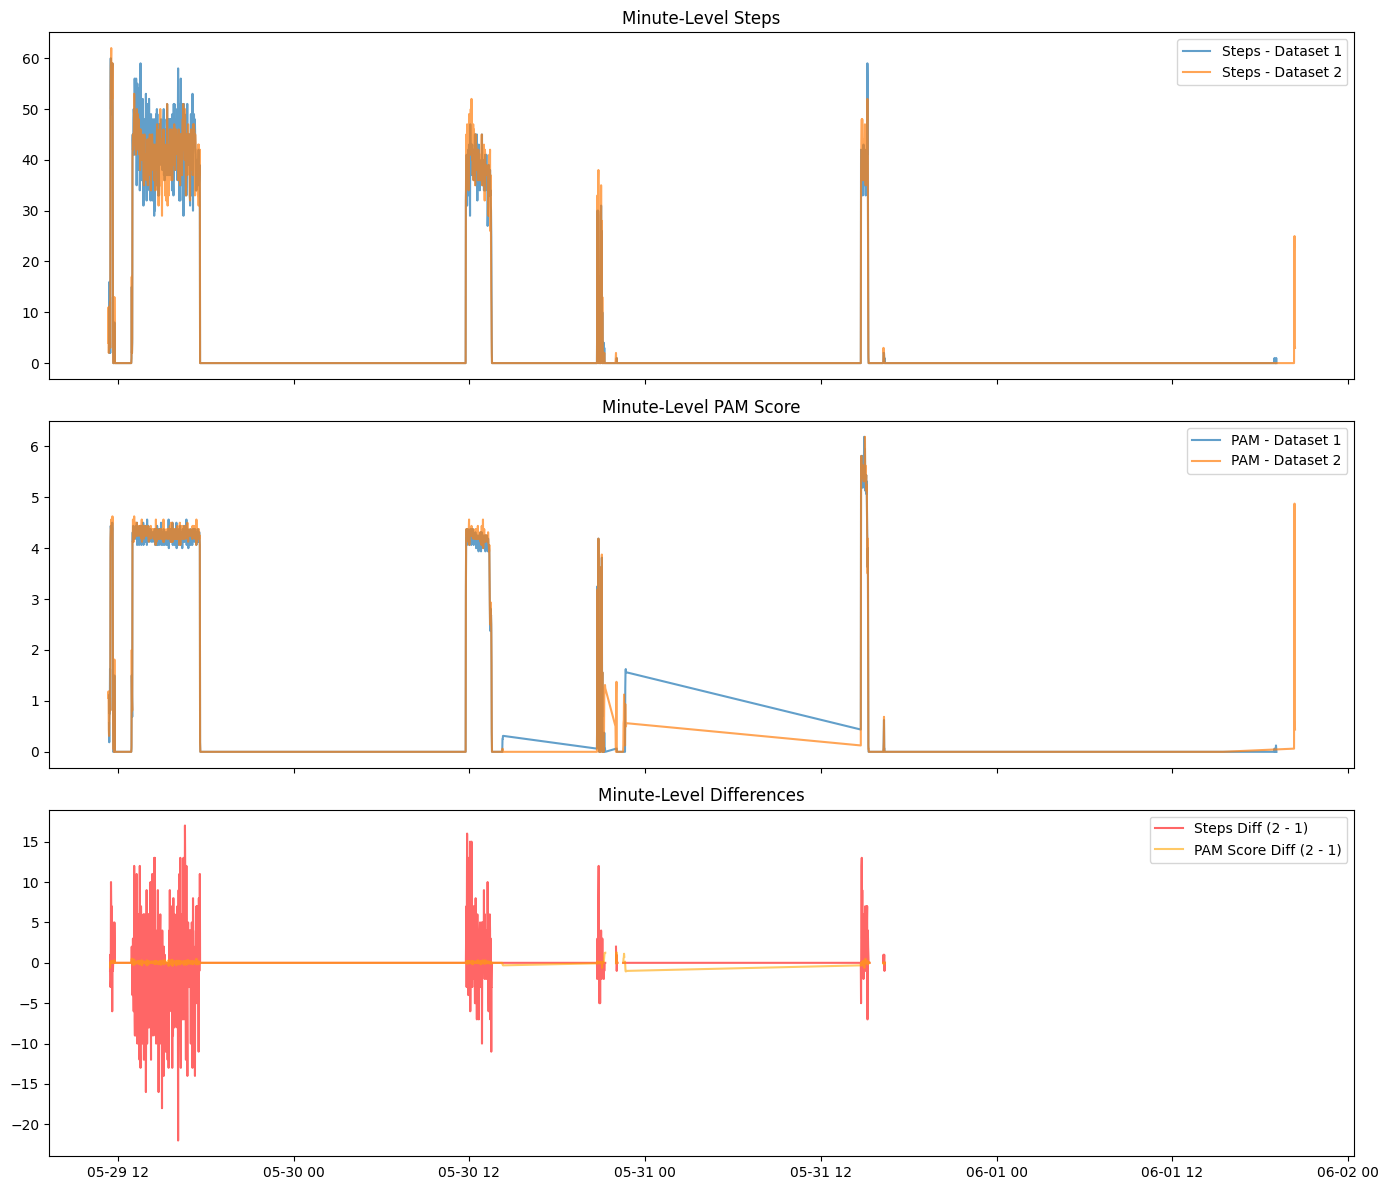

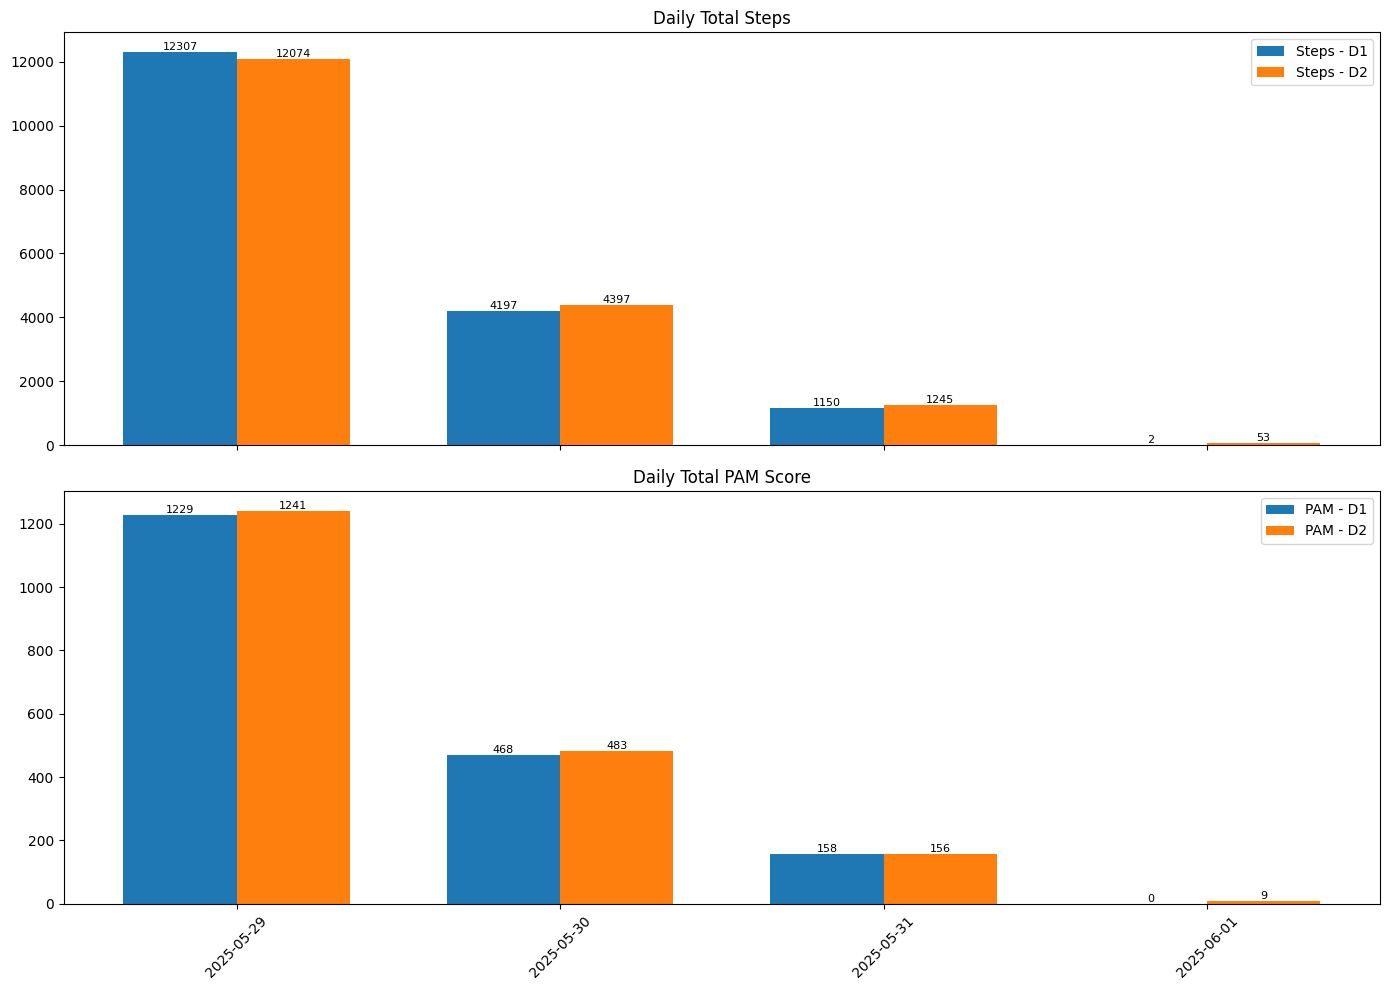

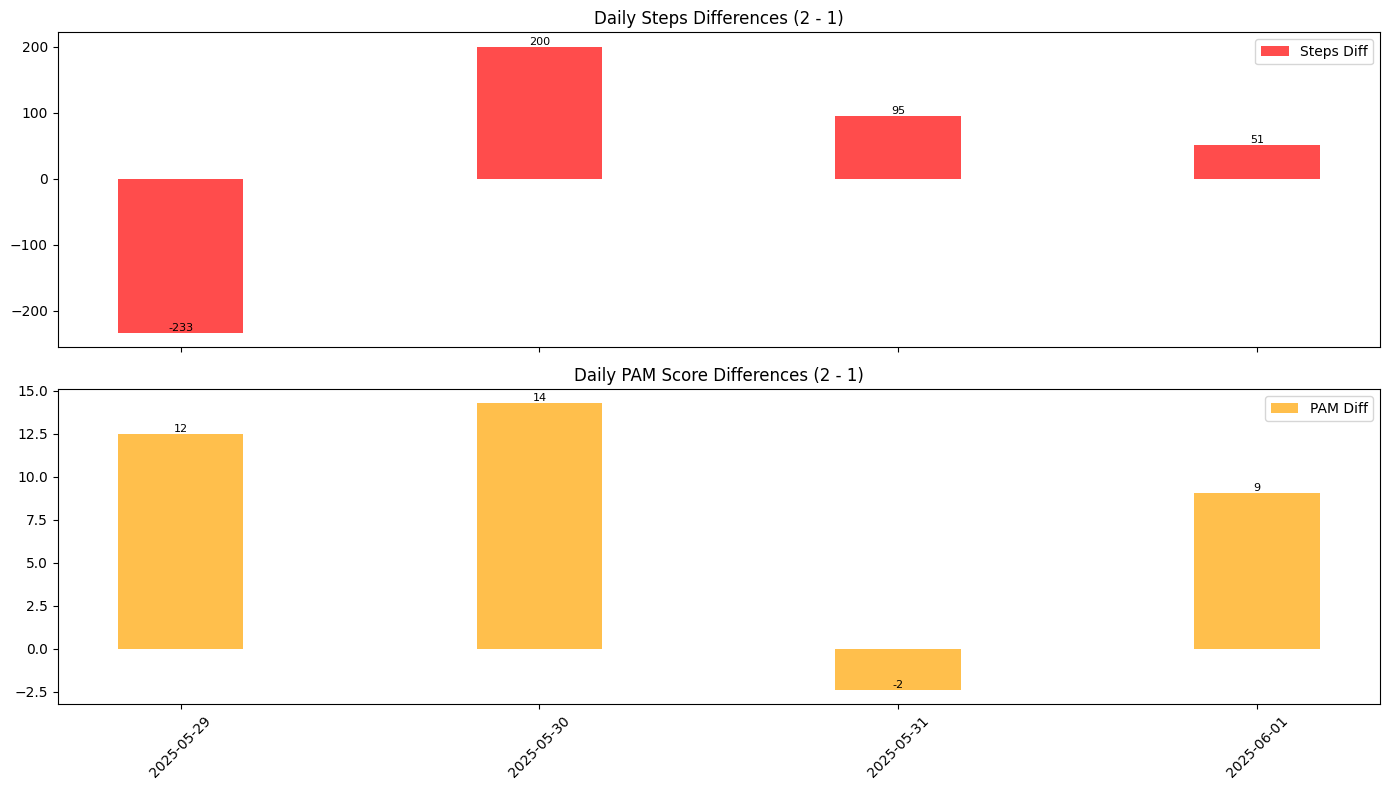

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the minute-level data
df1 = pd.read_csv("./data/device__8__3.csv", parse_dates=["Timestamp"])
df2 = pd.read_csv("./data/device__2__3.csv", parse_dates=["Timestamp"])

# Set timestamp as index
df1.set_index("Timestamp", inplace=True)
df2.set_index("Timestamp", inplace=True)

# --- 1. Plot raw minute-level data ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot Steps per minute
axes[0].plot(df1.index, df1["Steps"], label="Steps - Dataset 1", alpha=0.7)
axes[0].plot(df2.index, df2["Steps"], label="Steps - Dataset 2", alpha=0.7)
axes[0].set_title("Minute-Level Steps")
axes[0].legend()

# Plot PAM Score per minute
axes[1].plot(df1.index, df1["PAM Score"], label="PAM - Dataset 1", alpha=0.7)
axes[1].plot(df2.index, df2["PAM Score"], label="PAM - Dataset 2", alpha=0.7)
axes[1].set_title("Minute-Level PAM Score")
axes[1].legend()

# Plot differences
diff_steps = df2["Steps"] - df1["Steps"]
diff_pam = df2["PAM Score"] - df1["PAM Score"]

axes[2].plot(diff_steps.index, diff_steps, label="Steps Diff (2 - 1)", color="red", alpha=0.6)
axes[2].plot(diff_pam.index, diff_pam, label="PAM Score Diff (2 - 1)", color="orange", alpha=0.6)
axes[2].set_title("Minute-Level Differences")
axes[2].legend()

plt.tight_layout()
plt.show()

# --- 2. Resample to daily totals ---
df1_daily = df1.resample("D").sum()
df2_daily = df2.resample("D").sum()
daily_diff = df2_daily - df1_daily
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        if height != 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.0f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )


# --- 3. Plot daily totals ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Dataset 1 and 2 Steps total
bars1 = axes[0].bar(x - width/2, df1_daily["Steps"], width, label="Steps - D1")
bars2 = axes[0].bar(x + width/2, df2_daily["Steps"], width, label="Steps - D2")
axes[0].set_title("Daily Total Steps")
axes[0].legend()
add_labels(axes[0], bars1)
add_labels(axes[0], bars2)

# Dataset 1 and 2 PAM total
bars3 = axes[1].bar(x - width/2, df1_daily["PAM Score"], width, label="PAM - D1")
bars4 = axes[1].bar(x + width/2, df2_daily["PAM Score"], width, label="PAM - D2")
axes[1].set_title("Daily Total PAM Score")
axes[1].legend()
add_labels(axes[1], bars3)
add_labels(axes[1], bars4)

plt.xticks(ticks=x, labels=dates, rotation=45)
plt.tight_layout()
plt.show()

# --- 4. Plot daily differences separately ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Steps difference
bars5 = axes[0].bar(x, daily_diff["Steps"], width, label="Steps Diff", color="red", alpha=0.7)
axes[0].set_title("Daily Steps Differences (2 - 1)")
axes[0].legend()
add_labels(axes[0], bars5)

# PAM Score difference
bars6 = axes[1].bar(x, daily_diff["PAM Score"], width, label="PAM Diff", color="orange", alpha=0.7)
axes[1].set_title("Daily PAM Score Differences (2 - 1)")
axes[1].legend()
add_labels(axes[1], bars6)

plt.xticks(ticks=x, labels=dates, rotation=45)
plt.tight_layout()
plt.show()



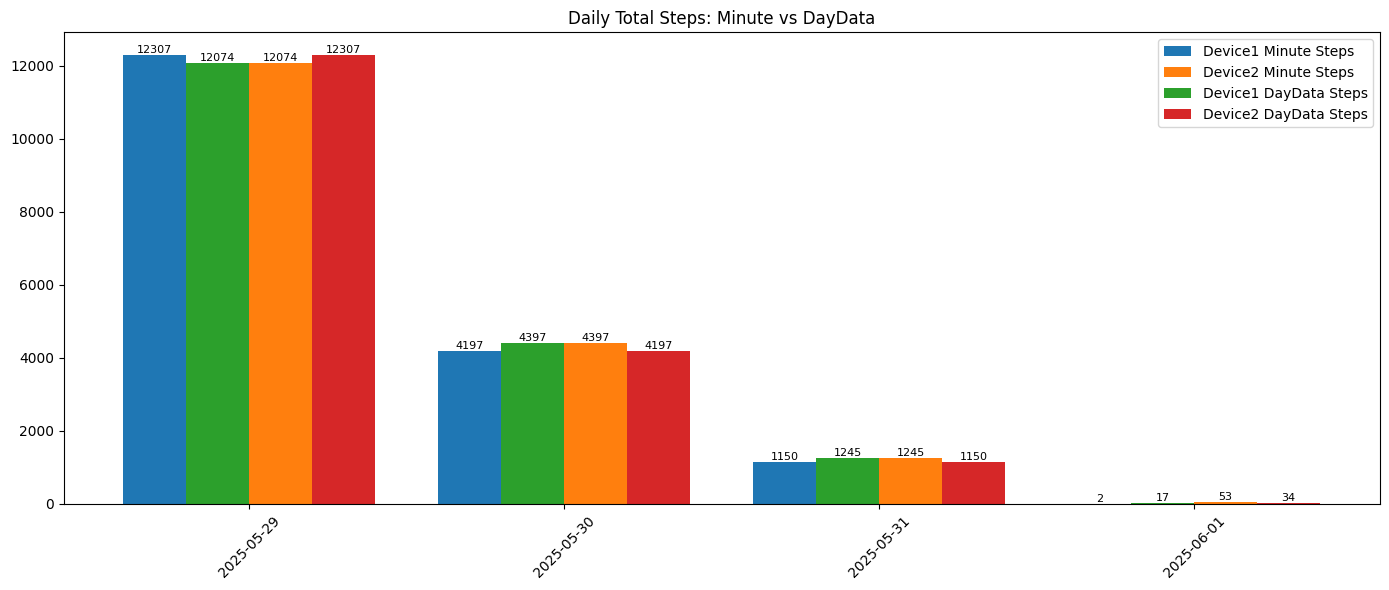

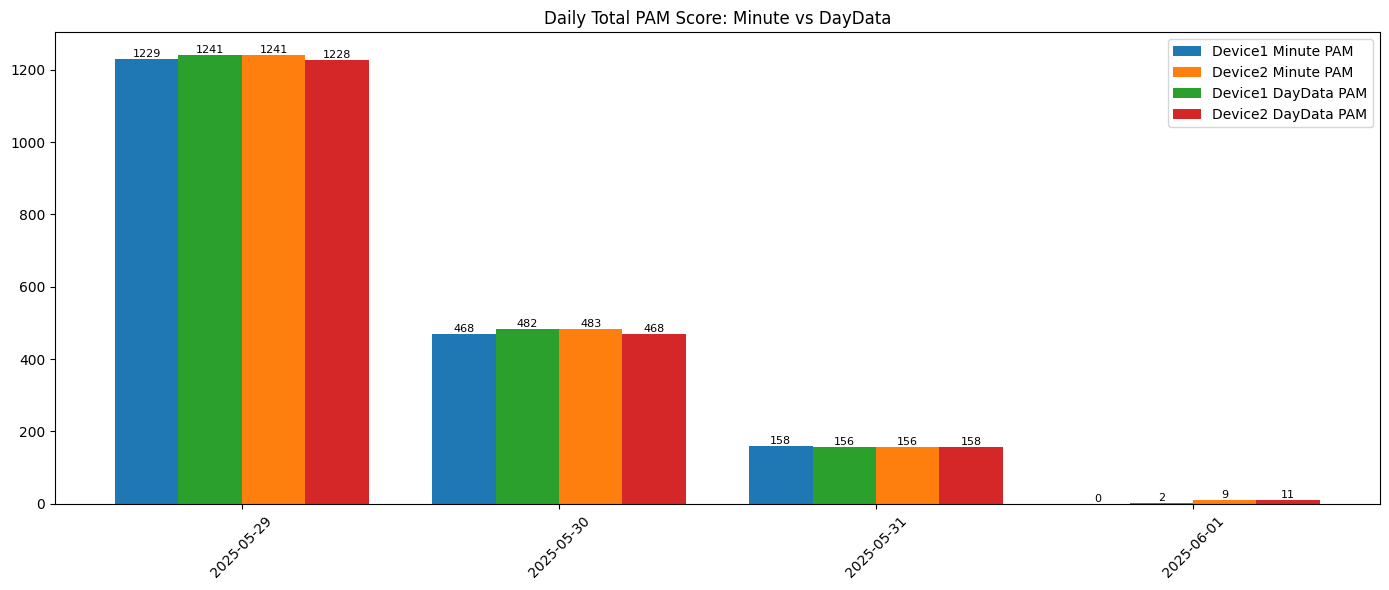

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load minute-level data
df1 = pd.read_csv("./data/device__8__3.csv", parse_dates=["Timestamp"])
df2 = pd.read_csv("./data/device__2__3.csv", parse_dates=["Timestamp"])

# Set Timestamp as index for minute-level
df1.set_index("Timestamp", inplace=True)
df2.set_index("Timestamp", inplace=True)

# Resample minute-level to daily totals
df1_daily = df1.resample("D").sum()
df2_daily = df2.resample("D").sum()

# Load daydata (daily) files
df_day1 = pd.read_csv("./data/dayData_90242_3_experiment.csv", encoding="utf-8-sig", parse_dates=["Date"])
df_day2 = pd.read_csv("./data/dayData_90248_3_experiment.csv", encoding="utf-8-sig", parse_dates=["Date"])

# Set Date as index for daydata
df_day1.set_index("Date", inplace=True)
df_day2.set_index("Date", inplace=True)

# Select relevant columns for comparison: Steps and Activity Score (PAM)
min_steps_1 = df1_daily["Steps"]
min_steps_2 = df2_daily["Steps"]
pam_min_1   = df1_daily["PAM Score"]
pam_min_2   = df2_daily["PAM Score"]

day_steps_1 = df_day1["Steps"]
day_steps_2 = df_day2["Steps"]
day_pam_1   = df_day1["Activity Score"]
day_pam_2   = df_day2["Activity Score"]

# Align dates across all four series
common_dates = (
    df1_daily.index
    .intersection(df2_daily.index)
    .intersection(df_day1.index)
    .intersection(df_day2.index)
)

min_steps_1 = min_steps_1.loc[common_dates]
min_steps_2 = min_steps_2.loc[common_dates]
pam_min_1   = pam_min_1.loc[common_dates]
pam_min_2   = pam_min_2.loc[common_dates]

day_steps_1 = day_steps_1.loc[common_dates]
day_steps_2 = day_steps_2.loc[common_dates]
day_pam_1   = day_pam_1.loc[common_dates]
day_pam_2   = day_pam_2.loc[common_dates]

# Prepare for plotting
dates_str = common_dates.strftime("%Y-%m-%d")
x = np.arange(len(common_dates))
width = 0.2

# Function to add labels on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.0f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

# 1) Plot Steps comparison (4 bars per date)
fig, ax_steps = plt.subplots(figsize=(14, 6))

bars_a = ax_steps.bar(x - 1.5 * width, min_steps_1, width, label="Device1 Minute Steps")
bars_b = ax_steps.bar(x + 0.5 * width, min_steps_2, width, label="Device2 Minute Steps")
bars_c = ax_steps.bar(x - 0.5 * width, day_steps_1, width, label="Device1 DayData Steps")
bars_d = ax_steps.bar(x + 1.5 * width, day_steps_2, width, label="Device2 DayData Steps")

ax_steps.set_title("Daily Total Steps: Minute vs DayData")
ax_steps.set_xticks(x)
ax_steps.set_xticklabels(dates_str, rotation=45)
ax_steps.legend()

add_labels(ax_steps, bars_a)
add_labels(ax_steps, bars_b)
add_labels(ax_steps, bars_c)
add_labels(ax_steps, bars_d)

plt.tight_layout()
plt.show()

# 2) Plot PAM Score comparison (4 bars per date)
fig, ax_pam = plt.subplots(figsize=(14, 6))

bars_e = ax_pam.bar(x - 1.5 * width, pam_min_1, width, label="Device1 Minute PAM")
bars_f = ax_pam.bar(x + 0.5 * width, pam_min_2, width, label="Device2 Minute PAM")
bars_g = ax_pam.bar(x - 0.5 * width, day_pam_1, width, label="Device1 DayData PAM")
bars_h = ax_pam.bar(x + 1.5 * width, day_pam_2, width, label="Device2 DayData PAM")

ax_pam.set_title("Daily Total PAM Score: Minute vs DayData")
ax_pam.set_xticks(x)
ax_pam.set_xticklabels(dates_str, rotation=45)
ax_pam.legend()

add_labels(ax_pam, bars_e)
add_labels(ax_pam, bars_f)
add_labels(ax_pam, bars_g)
add_labels(ax_pam, bars_h)

plt.tight_layout()
plt.show()


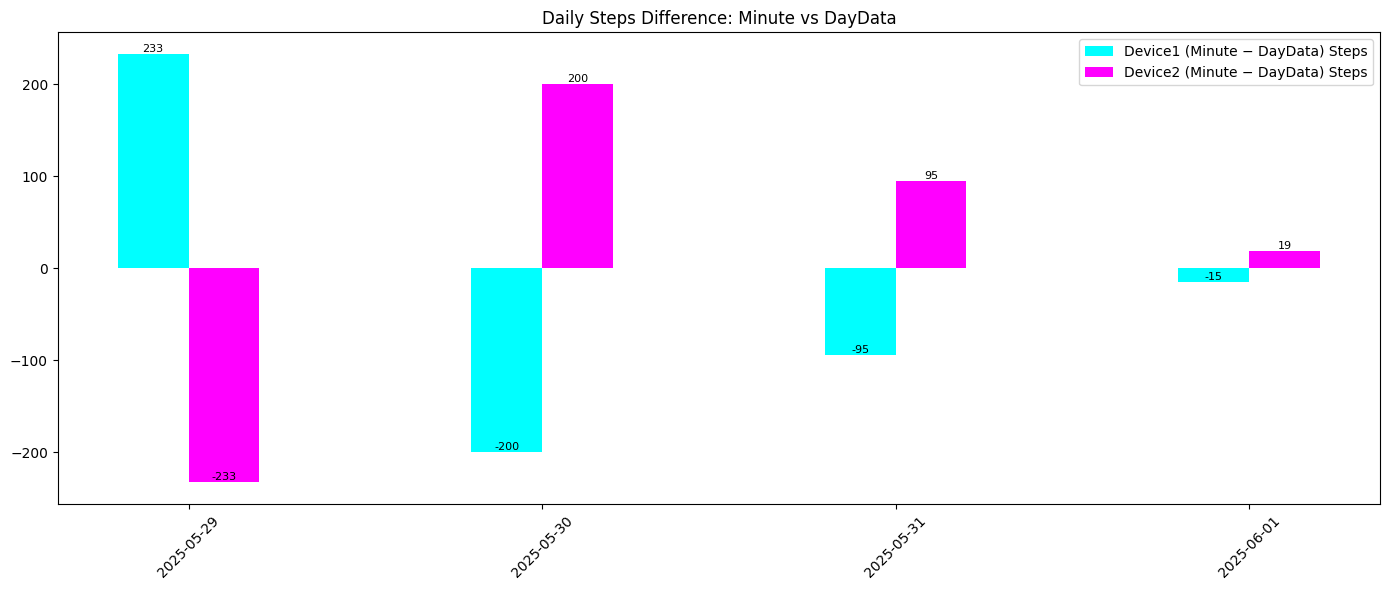

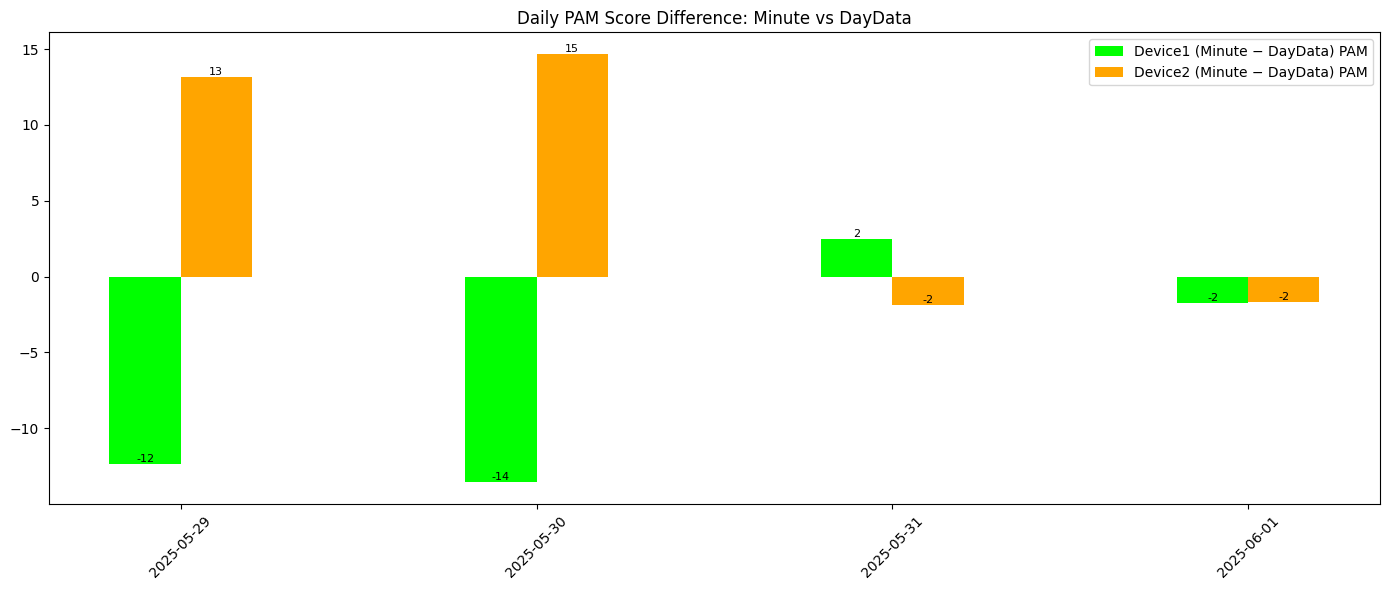

In [38]:
# Compute differences between minute-level and daydata for each device
diff_steps_1 = min_steps_1 - day_steps_1
diff_steps_2 = min_steps_2 - day_steps_2

diff_pam_1 = pam_min_1 - day_pam_1
diff_pam_2 = pam_min_2 - day_pam_2

# Prepare for plotting differences
# (dates_str, x, and width are already defined from before)

# 1) Plot Steps differences (2 bars per date: Device1 diff, Device2 diff)
fig, ax_diff_steps = plt.subplots(figsize=(14, 6))

bars_ds1 = ax_diff_steps.bar(x - width / 2, diff_steps_1, width, label="Device1 (Minute − DayData) Steps", color="cyan")
bars_ds2 = ax_diff_steps.bar(x + width / 2, diff_steps_2, width, label="Device2 (Minute − DayData) Steps", color="magenta")

ax_diff_steps.set_title("Daily Steps Difference: Minute vs DayData")
ax_diff_steps.set_xticks(x)
ax_diff_steps.set_xticklabels(dates_str, rotation=45)
ax_diff_steps.legend()

# Add value labels on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.0f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

add_labels(ax_diff_steps, bars_ds1)
add_labels(ax_diff_steps, bars_ds2)

plt.tight_layout()
plt.show()


# 2) Plot PAM Score differences (2 bars per date: Device1 diff, Device2 diff)
fig, ax_diff_pam = plt.subplots(figsize=(14, 6))

bars_dp1 = ax_diff_pam.bar(x - width / 2, diff_pam_1, width, label="Device1 (Minute − DayData) PAM", color="lime")
bars_dp2 = ax_diff_pam.bar(x + width / 2, diff_pam_2, width, label="Device2 (Minute − DayData) PAM", color="orange")

ax_diff_pam.set_title("Daily PAM Score Difference: Minute vs DayData")
ax_diff_pam.set_xticks(x)
ax_diff_pam.set_xticklabels(dates_str, rotation=45)
ax_diff_pam.legend()

add_labels(ax_diff_pam, bars_dp1)
add_labels(ax_diff_pam, bars_dp2)

plt.tight_layout()
plt.show()


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load minute-level data
df1 = pd.read_csv("./data/device__8__3.csv", parse_dates=["Timestamp"])
df2 = pd.read_csv("./data/device__2__3.csv", parse_dates=["Timestamp"])

# Set Timestamp as index for minute-level
df1.set_index("Timestamp", inplace=True)
df2.set_index("Timestamp", inplace=True)

# Resample minute-level to daily totals
df1_daily = df1.resample("D").sum()
df2_daily = df2.resample("D").sum()

# Load daydata (daily) files
df_day1 = pd.read_csv("./data/dayData_90242_3_experiment.csv", encoding="utf-8-sig", parse_dates=["Date"])
df_day2 = pd.read_csv("./data/dayData_90248_3_experiment.csv", encoding="utf-8-sig", parse_dates=["Date"])

# Set Date as index for daydata
df_day1.set_index("Date", inplace=True)
df_day2.set_index("Date", inplace=True)

# Select relevant columns for comparison: Steps and Activity Score (PAM)
min_steps_1 = df1_daily["Steps"]
min_steps_2 = df2_daily["Steps"]
pam_min_1   = df1_daily["PAM Score"]
pam_min_2   = df2_daily["PAM Score"]

day_steps_1 = df_day1["Steps"]
day_steps_2 = df_day2["Steps"]
day_pam_1   = df_day1["Activity Score"]
day_pam_2   = df_day2["Activity Score"]

# Align dates across all four series
common_dates = (
    df1_daily.index
        .intersection(df2_daily.index)
        .intersection(df_day1.index)
        .intersection(df_day2.index)
)

min_steps_1 = min_steps_1.loc[common_dates]
min_steps_2 = min_steps_2.loc[common_dates]
pam_min_1   = pam_min_1.loc[common_dates]
pam_min_2   = pam_min_2.loc[common_dates]

day_steps_1 = day_steps_1.loc[common_dates]
day_steps_2 = day_steps_2.loc[common_dates]
day_pam_1   = day_pam_1.loc[common_dates]
day_pam_2   = day_pam_2.loc[common_dates]

# Compute differences between minute-level and daydata for each device
diff_steps_1 = min_steps_1 - day_steps_1
diff_steps_2 = min_steps_2 - day_steps_2

diff_pam_1 = pam_min_1 - day_pam_1
diff_pam_2 = pam_min_2 - day_pam_2

# Prepare for plotting
dates_str = common_dates.strftime("%Y-%m-%d")
x = np.arange(len(common_dates))
width = 0.2

# Function to add labels on top of bars
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.0f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

# 1) Plot Steps comparison (4 bars per date)
fig, ax_steps = plt.subplots(figsize=(14, 6))

bars_a = ax_steps.bar(x - 1.5 * width, min_steps_1, width, label="Device1 Minute Steps")
bars_b = ax_steps.bar(x - 0.5 * width, day_steps_1, width, label="Device1 DayData Steps")
bars_c = ax_steps.bar(x + 0.5 * width, min_steps_2, width, label="Device2 Minute Steps")
bars_d = ax_steps.bar(x + 1.5 * width, day_steps_2, width, label="Device2 DayData Steps")

ax_steps.set_title("Daily Total Steps: Minute vs DayData")
ax_steps.set_xticks(x)
ax_steps.set_xticklabels(dates_str, rotation=45)
ax_steps.legend()

add_labels(ax_steps, bars_a)
add_labels(ax_steps, bars_b)
add_labels(ax_steps, bars_c)
add_labels(ax_steps, bars_d)

plt.tight_layout()
fig.savefig("daily_steps_comparison.png")
plt.close(fig)

# 2) Plot PAM Score comparison (4 bars per date)
fig, ax_pam = plt.subplots(figsize=(14, 6))

bars_e = ax_pam.bar(x - 1.5 * width, pam_min_1, width, label="Device1 Minute PAM")
bars_f = ax_pam.bar(x - 0.5 * width, day_pam_1, width, label="Device1 DayData PAM")
bars_g = ax_pam.bar(x + 0.5 * width, pam_min_2, width, label="Device2 Minute PAM")
bars_h = ax_pam.bar(x + 1.5 * width, day_pam_2, width, label="Device2 DayData PAM")

ax_pam.set_title("Daily Total PAM Score: Minute vs DayData")
ax_pam.set_xticks(x)
ax_pam.set_xticklabels(dates_str, rotation=45)
ax_pam.legend()

add_labels(ax_pam, bars_e)
add_labels(ax_pam, bars_f)
add_labels(ax_pam, bars_g)
add_labels(ax_pam, bars_h)

plt.tight_layout()
fig.savefig("daily_pam_comparison.png")
plt.close(fig)

# 3) Plot Steps differences (2 bars per date: Device1 diff, Device2 diff)
fig, ax_diff_steps = plt.subplots(figsize=(14, 6))

bars_ds1 = ax_diff_steps.bar(x - width / 2, diff_steps_1, width, label="Device1 (Minute − DayData) Steps", color="cyan")
bars_ds2 = ax_diff_steps.bar(x + width / 2, diff_steps_2, width, label="Device2 (Minute − DayData) Steps", color="magenta")

ax_diff_steps.set_title("Daily Steps Difference: Minute vs DayData")
ax_diff_steps.set_xticks(x)
ax_diff_steps.set_xticklabels(dates_str, rotation=45)
ax_diff_steps.legend()

add_labels(ax_diff_steps, bars_ds1)
add_labels(ax_diff_steps, bars_ds2)

plt.tight_layout()
fig.savefig("daily_steps_difference.png")
plt.close(fig)

# 4) Plot PAM Score differences (2 bars per date: Device1 diff, Device2 diff)
fig, ax_diff_pam = plt.subplots(figsize=(14, 6))

bars_dp1 = ax_diff_pam.bar(x - width / 2, diff_pam_1, width, label="Device1 (Minute − DayData) PAM", color="lime")
bars_dp2 = ax_diff_pam.bar(x + width / 2, diff_pam_2, width, label="Device2 (Minute − DayData) PAM", color="orange")

ax_diff_pam.set_title("Daily PAM Score Difference: Minute vs DayData")
ax_diff_pam.set_xticks(x)
ax_diff_pam.set_xticklabels(dates_str, rotation=45)
ax_diff_pam.legend()

add_labels(ax_diff_pam, bars_dp1)
add_labels(ax_diff_pam, bars_dp2)

plt.tight_layout()
fig.savefig("daily_pam_difference.png")
plt.close(fig)
